In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../notebooks/DATA/heart.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [4]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


<Axes: xlabel='target', ylabel='count'>

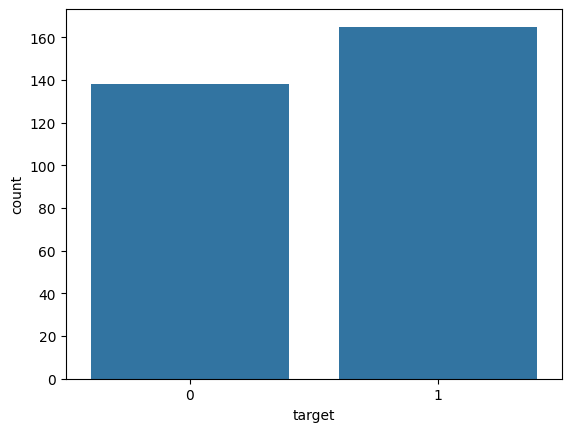

In [5]:
sns.countplot(data=df, x='target')

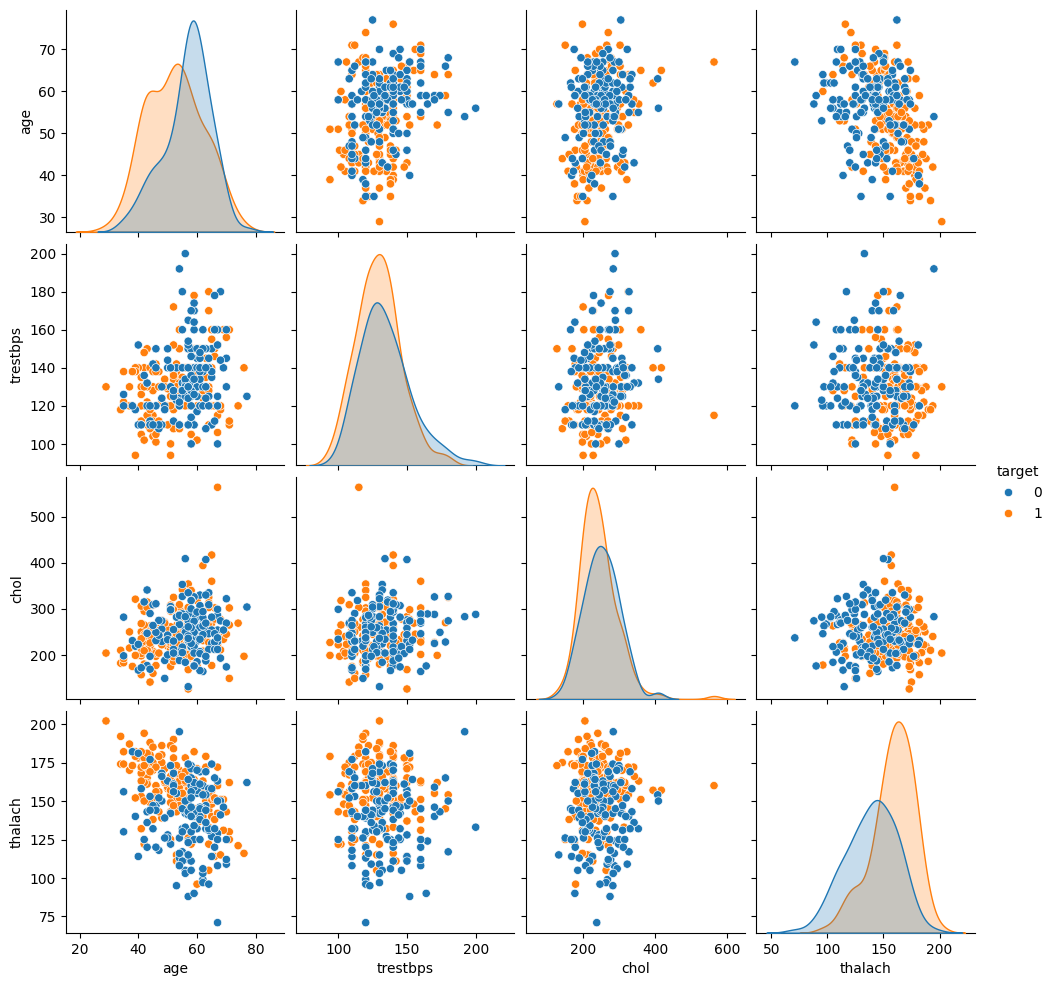

In [6]:
cols=['age', 'trestbps', 'chol', 'thalach', 'target']
sns.pairplot(df[cols], hue='target')

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X = df.drop('target', axis=1)
y = df['target']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.12, random_state=42)

In [10]:
from sklearn.preprocessing import StandardScaler

In [11]:
scaler = StandardScaler()

In [12]:
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

In [13]:
from sklearn.linear_model import LogisticRegression

In [14]:
from sklearn.model_selection import GridSearchCV
from sklearn.multiclass import OneVsRestClassifier

In [15]:
log_model = LogisticRegression(solver='saga', max_iter=5000)
log_model = OneVsRestClassifier(log_model)

In [16]:
penalty = ['l1', 'l2', 'elastic_net']
l1_ratio = np.linspace(0,0.5,20)
C = np.logspace(-2, 2, 20)

param_grid = [
    {
        'estimator__penalty': ['l1', 'l2'],
        'estimator__C': C
    },
    {
        'estimator__penalty': ['elasticnet'],
        'estimator__C': C,
        'estimator__l1_ratio': l1_ratio
    }
]

In [17]:
grid_model = GridSearchCV(log_model, param_grid=param_grid)

In [18]:
grid_model.fit(scaled_X_train, y_train)

,estimator,OneVsRestClas...olver='saga'))
,param_grid,"[{'estimator__C': array([1.0000...00000000e+02]), 'estimator__penalty': ['l1', 'l2']}, {'estimator__C': array([1.0000...00000000e+02]), 'estimator__l1_ratio': array([0. ..., 0.5 ]), 'estimator__penalty': ['elasticnet']}]"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'elasticnet'


In [19]:
par = grid_model.best_params_
par

{'estimator__C': np.float64(0.026366508987303583),
 'estimator__l1_ratio': np.float64(0.3684210526315789),
 'estimator__penalty': 'elasticnet'}

In [20]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [21]:
y_pred = grid_model.predict(scaled_X_test)

In [22]:
accuracy_score(y_test, y_pred)

0.8378378378378378

In [23]:
confusion_matrix(y_test, y_pred)

array([[14,  3],
       [ 3, 17]])

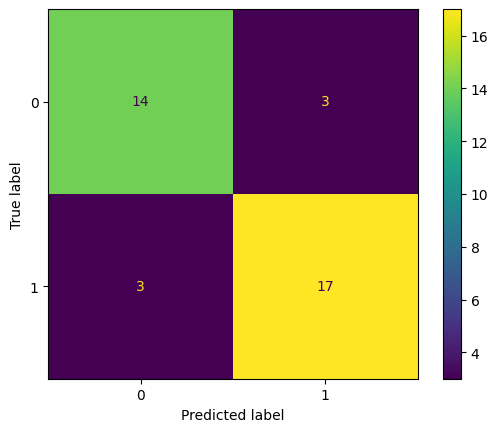

In [24]:
ConfusionMatrixDisplay.from_estimator(grid_model, scaled_X_test, y_test)

In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.82      0.82        17
           1       0.85      0.85      0.85        20

    accuracy                           0.84        37
   macro avg       0.84      0.84      0.84        37
weighted avg       0.84      0.84      0.84        37



In [26]:
from sklearn.metrics import  RocCurveDisplay

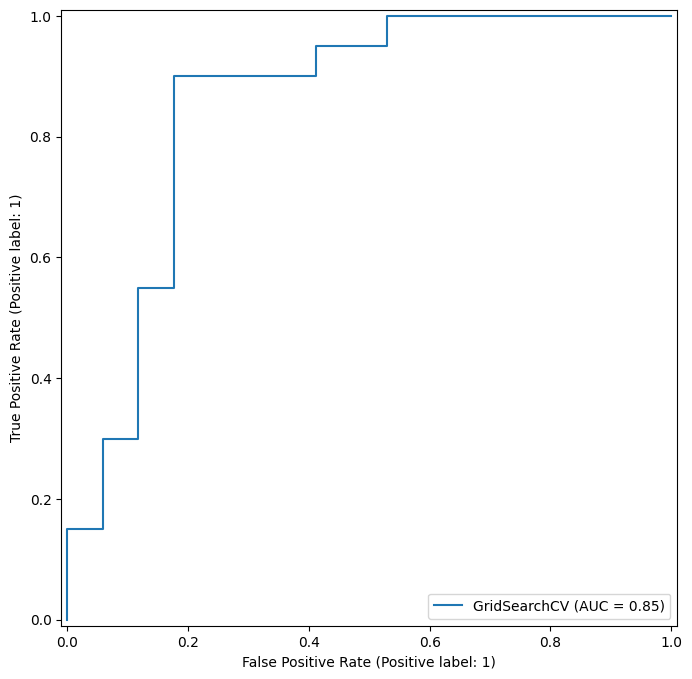

In [27]:
fig, ax = plt.subplots(figsize=(12,8),dpi=100)
RocCurveDisplay.from_estimator(grid_model, scaled_X_test, y_test, ax=ax)

In [28]:
patient = [[ 54. ,   1. ,   0. , 122. , 286. ,   0. ,   0. , 116. ,   1. ,
          3.2,   1. ,   2. ,   2. ]]

In [29]:
grid_model.predict(scaler.transform(patient))

C:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([0])

In [30]:
grid_model.predict_proba(scaler.transform(patient))

C:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.86628905, 0.13371095]])